# Market Seams — Two Markets, One Network

> **Work in progress** — an illustrative teaching notebook under active development, not an authoritative reference.

Security constrained economic dispatch was introduced as one dispatch over
a network in 101. This notebook generalizes the market
clearing engine as an object: a set of resources it dispatches, a set of loads
it serves, and a set of transmission constraints it enforces, on a network. Stated that way, "one market" is just
the special case where a single engine's sets span the whole network. A market seam is
what appears when two or more engines, with separate sets of resources and loads, optimize dispatch on the same grid at the same time.

This notebook formulates the market seam, provides a worked example on the WSCC 9-bus test case, and provides a sandbox to configure the market and its input variables. The two
coordination problems between market seams — managing congestion on shared constraints,
and scheduling interchange between the footprints — are worked in depth in 204
(congestion and constraint management) and 205 (interchange).

Everything runs on the shared libraries — `wscc9_model`, `footprints`,
`seams_engine`, `wscc9_figures`.


## 0. Setup


In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# helper modules next to the notebook. Running locally it does nothing (the
# modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
               "wscc9_model.py", "footprints.py", "revenue_allocation.py",
               "wscc9_figures.py", "atc.py", "bilateral.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")

Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures, atc
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures, atc):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)
print('ready')

ready

In [3]:
# The teaching fleet and loads live in wscc9_model. Market A holds the cheap fleet
# (bus 3 $20, bus 2 $35); Market B holds only the expensive bus-1 unit ($50).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)
LOADS     = dict(wm.DEFAULT_LOADS)
print('loads (MW):', LOADS, ' total', sum(LOADS.values()))
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

 total

315.0

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. The market clearing engine — three sets on a shared network

**Nomenclature.** Sets are script capitals; an element is the matching
lower-case letter (upper-case for markets). The `Code` column is where each
object lives in the shared libraries.

| Symbol | Code | Definition |
|---|---|---|
| $\mathcal N$, $\mathcal M$ | `pt.buses` / `pt.lines` | buses, and the **network line set** — every line in the shared network; $n\in\mathcal N$, $m\in\mathcal M$ |
| $SF_{n,m}$, $\bar F_m$ | `pt` (`compute_ptdf`) / `LINE_RATINGS` | shift factor of bus $n$ on line $m$; line $m$'s operating limit — shared physics, owned by no engine |
| $\mathcal E$ | `make_engine` | the set of market engines on the shared network; $M\in\mathcal E=\{A,B\}$ here |
| $\mathcal R^{M}$ | `eng.gens` | the resources market $M$ dispatches; $i\in\mathcal R^{M}$ with offer $c_i$, capacity $\bar g_i$, host bus $\mathrm{bus}(i)$ |
| $\mathcal D^{M}$, $d^M_n$ | `eng.loads` | the loads market $M$ serves, and the MW at bus $n$ (zero wherever $M$ serves none) |
| $\mathcal M^{M}_{\text{mon}}\subseteq\mathcal M$ | `MONITORED_LINES` | market $M$'s **monitored lines** — the subset of the network line set it models and watches (Section 2) |
| $\mathcal M^{M}_{\text{act}}\subseteq\mathcal M^{M}_{\text{mon}}$ | `eng.activated_lines` (`ACTIVATED_LINES`) | the **activated constraint set** — the monitored lines whose limits market $M$ enforces |
| $\mathcal N_A$, $\mathcal N_B$ | `MKT_DEFS` | the two footprints — a partition of $\mathcal N$ (Section 2) |
| intertie lines | `fp.ties` | the lines crossing the footprint partition; which market monitors or activates them is configuration (Section 2) |
| $g^{M}_i$ | `res.dispatch` | dispatch of resource $i$ — the engine's decision variable, $0\le g^{M}_i\le\bar g_i$ |
| $\mathrm{exo}^{M}_n$ | `exo=` | exogenous scheduled injection at bus $n$, fixed before the clear (zero throughout this notebook; the interchange notebooks 205/212 use it) |
| $p^{\mathrm{inj},M}_n$ | `res.injection` | market $M$'s net injection at bus $n$: $g^{M}_n-d^{M}_n+\mathrm{exo}^{M}_n$ |
| $F^{M}_m$ | `res.flow_own` | market $M$'s **own** flow on line $m$ — computed for every $m\in\mathcal M$, priced only on $\mathcal M^{M}_{\text{act}}$ |
| $F^{s}_m$ | `physical_flows` | the **superposed flow** $\sum_M F^{M}_m$ — what the transmission element actually carries (Section 4) |
| $\lambda^{M}$, $\lambda^{M}_n$ | `res.energy_price` / `res.lmp` | market $M$'s energy price, and its nodal LMP at every bus |
| $\mu^{M}_m$ | `res.line_dual` | signed dual of activated line $m$ (zero off $\mathcal M^{M}_{\text{act}}$) |
| $R^{M}$ | — | market $M$'s congestion rent (eq. 5) |
| $u_n$, $V$ | `res.shed_by_bus` / `SHED_PRICE` | shed load at bus $n$ and its penalty price, \$/MWh (the power-balance relaxation) |

Note: lower-case $m$ indexes a **line**, script $\mathcal M$ is the set of lines, and upper-case $M$ identifies a **market engine**. 

In this notebook each engine's footprint is one of the two
bus sets, so the engine label and the footprint label coincide ($A$, $B$); in
the intra-market notebooks the same superscript ranges over a single unified
engine instead.

A market clearing engine is defined, in this simplified representation of market clearing, by the set of generators, loads, and lines it optimizes. 

$$M \;=\; \big(\;\mathcal R^{M},\ \mathcal D^{M},\ \mathcal M^{M}_{\text{act}}\;\big)\qquad\text{on the shared network }\big(\mathcal N,\ \mathcal M,\ SF_{n,m}\big). \tag{1}$$

*In words.* Engine $M$ is the resource set $\mathcal R^{M}$,
load set $\mathcal D^{M}$, and activated constraint set
$\mathcal M^{M}_{\text{act}}$. The engine is defined on the shared network of buses
$\mathcal N$, the network line set $\mathcal M$, and shift factors $SF_{n,m}$.

- $\mathcal R^{M}$ — the **resource stack** the engine dispatches: each resource $i$ with offer $c_i$, capacity $\bar g_i$, and host bus $\mathrm{bus}(i)$;
- $\mathcal D^{M}$ — the **loads** it serves, $d^M_n$ at its buses;
- $\mathcal M^{M}_{\text{act}} \subseteq \mathcal M$ — the **activated constraint set**: the transmission limits this engine enforces.

The network is *not* part of the engine. Buses $\mathcal N$, the network line
set $\mathcal M$, ratings $\bar F_m$, and the shift factors $SF_{n,m}$ are shared
physics — every engine on the grid computes flows from the same matrix. The
engine's own injections load **every** line, activated or not:

$$F^{M}_m \;=\; \sum_{n\in\mathcal N} SF_{n,m}\;p^{\mathrm{inj},M}_n,\qquad p^{\mathrm{inj},M}_n = g^{M}_n - d^{M}_n + \mathrm{exo}^{M}_n,\qquad m\in\mathcal M, \tag{2}$$

*In words.* Engine $M$'s flow on line $m$, $F^{M}_m$, is each bus's shift
factor on that line times $M$'s net injection there, summed over every bus.
The net injection $p^{\mathrm{inj},M}_n$ is $M$'s generation at bus $n$, minus
the load it serves there, plus any fixed schedule $\mathrm{exo}^{M}_n$. The
flow is computed for every line $m\in\mathcal M$, activated or not.

The engine **prices** only the activated set of constraints. Its clearing is the familiar
bid-based dispatch, restricted to its own three sets:

$$\min_{g}\ \sum_{i\in\mathcal R^{M}} c_i\,g^{M}_i \quad\text{s.t.}\quad \sum_{i\in\mathcal R^{M}} g^{M}_i = \sum_{n} d^{M}_n\ \ [\lambda^{M}],\qquad -\bar F_m \le F^{M}_m \le \bar F_m\ \ [\mu^{M}_m],\ m\in\mathcal M^{M}_{\text{act}}. \tag{3}$$

*In words.* Engine $M$ minimizes the offer cost of its own dispatch,
$\sum c_i\,g^{M}_i$ over $i\in\mathcal R^{M}$, subject to two constraint
families: its generation equals its served load (dual $\lambda^{M}$, the
engine's energy price), and its own flow $F^{M}_m$ stays within the rating
$\bar F_m$ on each activated line $m\in\mathcal M^{M}_{\text{act}}$ (dual
$\mu^{M}_m$, that line's shadow price). Lines outside
$\mathcal M^{M}_{\text{act}}$ appear in no constraint.

A constraint outside $\mathcal M^{M}_{\text{act}}$ is still in the engine's
network model — its flow is computed by (2) — but its limit is relaxed, so the
engine *sees* the flow it causes there and does not *price* it. The nodal price
follows the signed-$\mu$ decomposition, summed over the activated set only:

$$\lambda^{M}_n \;=\; \lambda^{M} + \sum_{m\in\mathcal M^{M}_{\text{act}}} SF_{n,m}\,\mu^{M}_m, \tag{4}$$

*In words.* Engine $M$'s price at bus $n$ is its energy price $\lambda^{M}$
plus, for each activated line $m$, the shift factor $SF_{n,m}$ times that
line's shadow price $\mu^{M}_m$. The sum runs over
$\mathcal M^{M}_{\text{act}}$ only, so a transmission element the engine does not
enforce contributes nothing to its prices.

and price separation across the engine's binding lines is its congestion rent,

$$R^{M} \;=\; \sum_{m\in\mathcal M^{M}_{\text{act}}} |\mu^{M}_m|\,|F^{M}_m| \;=\; \sum_n \lambda^{M}_n d^{M}_n - \sum_n \lambda^{M}_n g^{M}_n. \tag{5}$$

*In words.* Market $M$'s congestion rent $R^{M}$ — the money the clearing
collects because binding lines separate its prices — is the absolute shadow
price $|\mu^{M}_m|$ times the absolute flow $|F^{M}_m|$, summed over the
activated lines — equal to what
$M$'s load pays at its buses, $\sum\lambda^{M}_n d^{M}_n$, minus what $M$'s
generation is paid, $\sum\lambda^{M}_n g^{M}_n$. With no binding line every
$\mu^{M}_m$ is zero and $R^{M}=0$.

A single market clearing is the
special case where the sets span everything — $\mathcal R^M$ the whole fleet,
$\mathcal D^M$ all loads, $\mathcal M^M_{\text{act}}$ every line — and (3)
collapses to the one-market clearing.


## 2. Two markets on one network

This notebook considers two markets, $A$ and $B$, on the shared WSCC 9-bus network.
The buses are partitioned between two footprints, and every resource and
load participates in one market — the engines' sets are disjoint
even though the lines are common:

$$\mathcal N_A \cup \mathcal N_B = \mathcal N,\quad \mathcal N_A\cap\mathcal N_B=\emptyset;\qquad \mathcal R^{A}\cap\mathcal R^{B}=\emptyset,\qquad \mathcal D^{A}\cap\mathcal D^{B}=\emptyset. \tag{6}$$

*In words.* The bus set of footprint A, $\mathcal N_A$, combined with the bus
set of footprint B, $\mathcal N_B$, equals the bus set of the network,
$\mathcal N$, and no bus is in both. Likewise no resource is in both resource
sets $\mathcal R^{A}$ and $\mathcal R^{B}$, and no load is in both load sets
$\mathcal D^{A}$ and $\mathcal D^{B}$.

Each engine's monitored lines are a subset of the network line set, and the
activated constraint set is a configurable subset of the monitored lines: 

$$\mathcal M^{M}_{\text{act}} \;\subseteq\; \mathcal M^{M}_{\text{mon}} \;\subseteq\; \mathcal M,\qquad M\in\{A,B\}. \tag{7}$$

*In words.* Market $M$'s monitored line set $\mathcal M^{M}_{\text{mon}}$ is
a chosen subset of the network line set $\mathcal M$ — the lines it models
and watches, with flows computed and reported. Its activated constraint set
$\mathcal M^{M}_{\text{act}}$ is a configurable subset of the monitored
lines — the ones whose limits enter its clearing (3). The two gaps are
different things: a line monitored but not activated is watched and left
unpriced — the market sees the flow it causes there and does not constrain
it; a line outside the monitored set is not watched at all, though the
physics of (2) still loads it. Nothing ties either choice to the footprint: a
market may monitor or activate a line whose endpoints lie entirely in the
other footprint, and a line may be activated by both markets, by one, or by
neither.

Two lines cross the footprint partition — the 5–6 line and the 8–9 line - are interties between the markets. The default configuration in this notebook follows
the map: each engine monitors and activates the lines internal to its own
footprint plus one of the two intertie lines — 5–6 to Market A, 8–9 to
Market B. The `MONITORED_LINES` and `ACTIVATED_LINES`
knobs below hold that default and take any line list for either market; the
Section 5 sandbox exposes the whole choice.

In [4]:
# -- EDIT -- the shared network (base ratings) ----------------------------
LINE_RATINGS = {}          # no internal limit binds in this baseline
SHED_PRICE   = 150.0       # $/MWh load-shed penalty (power-balance relaxation)
# -------------------------------------------------------------------------
net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

# -- EDIT -- the two market footprints and each market's monitored set -----
MKT_DEFS = {
    'Market A': ['2', '8', '7', '6', '3'],   # cheap fleet ($20 at 3, $35 at 2); load at 7 -> exporter
    'Market B': ['1', '9', '4', '5'],         # only the $50 unit at bus 1; loads 5, 9 -> importer
}
MARKET_COLORS = {'Market A': '#993AFF', 'Market B': '#2471A3'}
MONITORED_LINES = {   # M^M_mon -- the lines each market models and watches. ANY subset
    # of pt.lines per market; the default follows the map (internal + one seam line).
    'Market A': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2 (5-6) = A's seam line
    'Market B': ['line_0', 'line_1', 'line_7', 'line_8'],             # line_7 (8-9) = B's seam line
}
ACTIVATED_LINES = {   # M^M_act -- the monitored lines whose limits enter the clearing (eq. 7).
    # Must stay within the monitored set; the default activates everything monitored.
    'Market A': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],
    'Market B': ['line_0', 'line_1', 'line_7', 'line_8'],
}
# -------------------------------------------------------------------------
fp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, monitored=MONITORED_LINES, tie_label='intertie')
mkt_of     = fp.fp_of
seam_lines = fp.ties     # the intertie set I^AB

for _m in MKT_DEFS:   # activation is a subset of monitoring -- clip and say so
    _extra = [l for l in ACTIVATED_LINES[_m] if l not in MONITORED_LINES[_m]]
    if _extra:
        print(f'[!] {_m}: {_extra} activated but not monitored -> dropped (M_act must be within M_mon)')
        ACTIVATED_LINES[_m] = [l for l in ACTIVATED_LINES[_m] if l in MONITORED_LINES[_m]]

A = make_engine('Market A', MKT_DEFS['Market A'], activated=ACTIVATED_LINES['Market A'])
B = make_engine('Market B', MKT_DEFS['Market B'], activated=ACTIVATED_LINES['Market B'])

print('Market A buses:', MKT_DEFS['Market A'], '| monitors', MONITORED_LINES['Market A'])
print('Market B buses:', MKT_DEFS['Market B'], '| monitors', MONITORED_LINES['Market B'])
print()
# Line status: where each line sits vs what each market does with it.
def _status(l, m):
    if l in ACTIVATED_LINES[m]:  return 'enforces'
    if l in MONITORED_LINES[m]:  return 'monitors'
    return '--'
_rows = []
for l in pt.lines:
    b0, b1 = pt.line_buses[pt.line_idx[l]]
    loc = 'intertie' if l in seam_lines else f'internal {mkt_of(b0)}'
    _rows.append({'line': l, 'ends': f'{b0}-{b1}', 'location': loc,
                  **{m: _status(l, m) for m in MKT_DEFS}})
print('intertie lines (crossing the partition):', ', '.join(seam_lines),
      '-- monitoring and activation are configuration, not topology.')
display(pd.DataFrame(_rows).set_index('line'))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market A buses:

['2', '8', '7', '6', '3']

| monitors

['line_2', 'line_3', 'line_4', 'line_5', 'line_6']

...

['line_0', 'line_1', 'line_7', 'line_8']

intertie lines (crossing the partition):

line_2, line_7

-- monitoring and activation are configuration, not topology.

,ends,location,Market A,Market B
line,,,,
line_0,1-4,internal Market B,--,enforces
line_1,4-5,internal Market B,--,enforces
line_2,5-6,intertie,enforces,--
line_3,3-6,internal Market A,enforces,--
line_4,6-7,internal Market A,enforces,--
line_5,7-8,internal Market A,enforces,--
line_6,8-2,internal Market A,enforces,--
line_7,8-9,intertie,--,enforces
line_8,9-4,internal Market B,--,enforces


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


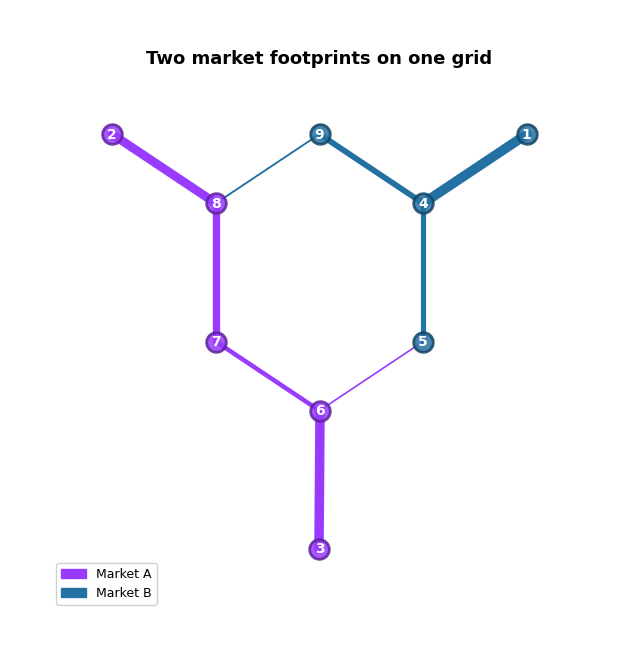

In [5]:
# Map of the two footprints (buses and lines coloured by market; interties grey).
mkt_bus_colors = {b: MARKET_COLORS[mkt_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=mkt_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=fp.line_colors(pt),      # lines coloured by their managing market
    title='Two market footprints on one grid',
)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=m) for m in MKT_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

## 3. The two clearings — and the unified counterfactual

Clear the two engines independently, each solving its own (3), on a network
with the 6–7 line rated at 40 MW — a limit inside Market A's footprint, in
its monitored and activated set. Every quantity now carries the market
superscript: two dispatches, two energy prices $\lambda^{A},\lambda^{B}$,
two flow vectors $F^{A}_m, F^{B}_m$ on the same lines — and, physically,
**one** grid that carries their superposition.

The counterfactual for the pair is the **unified special case**: one engine
whose sets are the unions,

$$\min_{g}\ C^{A}+C^{B}\quad\text{s.t.}\quad\text{one balance over }\mathcal N,\qquad m\in\mathcal M, \tag{8}$$

*In words.* One engine minimizes the combined dispatch cost $C^{A}+C^{B}$,
subject to a single power balance over all buses $\mathcal N$, with every
line in the network line set $\mathcal M$ monitored and enforced by the one
engine.

The ledger below compares the combined production cost of the two clearings
with the unified counterfactual's, on the same network. What that difference
is *worth* per scheduled megawatt — the envelope link to the price gap
between the engines, and who captures it — is the subject of 205.


In [6]:
# The example topology: the 6-7 line (line_4, internal to Market A) rated 40 MW.
netc = build_network({'line_4': 40.0})
ptc  = compute_ptdf(netc, slack_bus='1')
Ac = make_engine('Market A', MKT_DEFS['Market A'], activated=ACTIVATED_LINES['Market A'])
Bc = make_engine('Market B', MKT_DEFS['Market B'], activated=ACTIVATED_LINES['Market B'])
rA = solve_engine_dispatch(ptc, Ac, shed_price=SHED_PRICE)
rB = solve_engine_dispatch(ptc, Bc, shed_price=SHED_PRICE)
uniC = make_engine('UNIFIED', buses=ptc.buses)
resU = solve_engine_dispatch(ptc, uniC, shed_price=SHED_PRICE)

print(f"Market A: energy price ${rA.energy_price:>5.1f}/MWh   "
      f"dispatch {sum(rA.dispatch.values()):.0f} MW   cost ${rA.total_cost:,.0f}/h")
print(f"Market B: energy price ${rB.energy_price:>5.1f}/MWh   "
      f"dispatch {sum(rB.dispatch.values()):.0f} MW   cost ${rB.total_cost:,.0f}/h")
print()
ledger = pd.DataFrame([
    {'clearing': 'Market A (its own sets)',        'production cost ($/h)': round(rA.total_cost)},
    {'clearing': 'Market B (its own sets)',        'production cost ($/h)': round(rB.total_cost)},
    {'clearing': 'Two markets, combined',          'production cost ($/h)': round(rA.total_cost + rB.total_cost)},
    {'clearing': 'Unified counterfactual, eq. (8)', 'production cost ($/h)': round(resU.total_cost)},
    {'clearing': 'Difference',                     'production cost ($/h)': round(rA.total_cost + rB.total_cost - resU.total_cost)},
]).set_index('clearing')
display(ledger)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market A: energy price $ 27.7/MWh   dispatch 100 MW   cost $2,909/h

Market B: energy price $ 50.0/MWh   dispatch 215 MW   cost $10,750/h

,production cost ($/h)
clearing,
Market A (its own sets),2909
Market B (its own sets),10750
"Two markets, combined",13659
"Unified counterfactual, eq. (8)",8941
Difference,4717


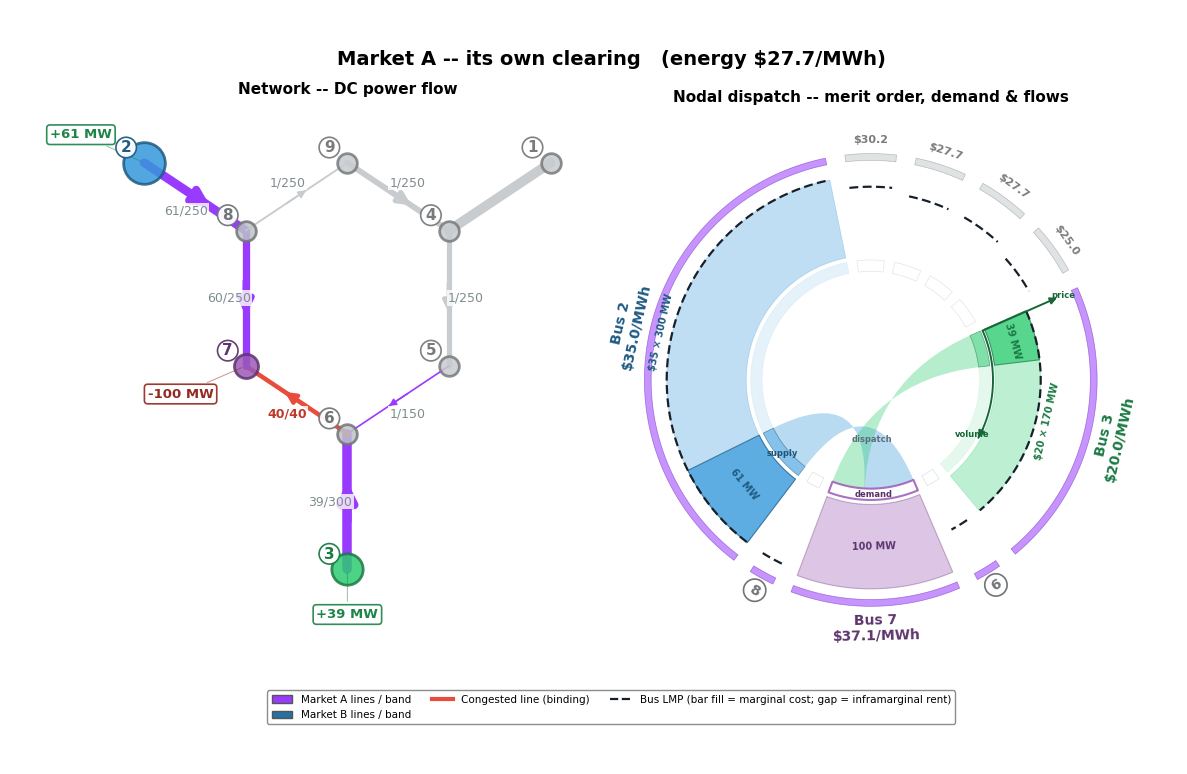

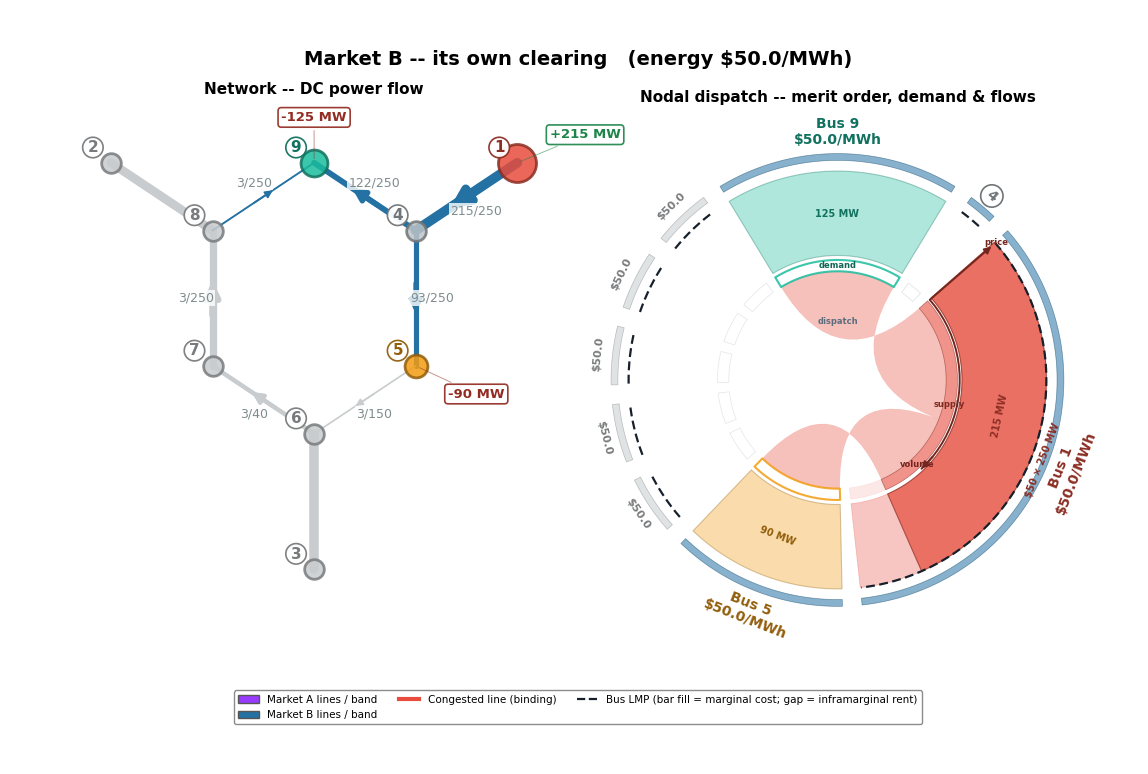

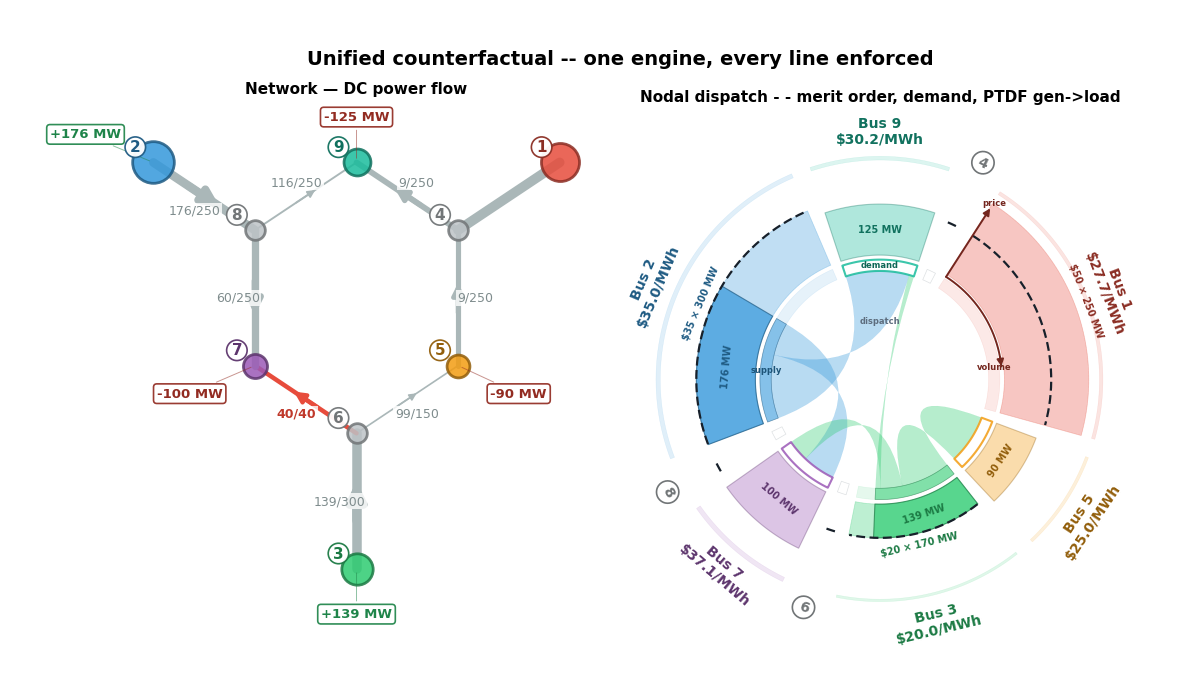

In [7]:
# One market's clearing as a combined set (network + nodal dispatch), the other
# footprint greyed; then the unified counterfactual on the same network.
def market_figure(net_, pt_, eng, res, **kw):
    kw.setdefault('node_net_mw', True)   # network panel: net injection/withdrawal; price on the ring
    return figs.footprint_figure(net_, pt_, fp, eng, res,
                                 highlight=eng.name, shed=False, **kw)

for eng, r in ((Ac, rA), (Bc, rB)):
    market_figure(netc, ptc, eng, r,
                  suptitle=f'{eng.name} -- its own clearing   (energy ${r.energy_price:.1f}/MWh)')
    plt.show()

supU, demU = to_supply_demand(uniC, resU)
bindU = {l for l, mu in resU.line_dual.items() if abs(mu) > 1e-3}
fig, _ = plot_combined_letter(
    netc, supU, demU,
    bus_colors=dict(BUS_COLORS), bus_lmps=resU.lmp,
    bus_net_mw={b: float(resU.injection[ptc.bus_idx[b]]) for b in ptc.buses},
    network_show_lmp=False,   # net injection/withdrawal on the network; price on the ring
    line_flows={l: resU.flow_own[l] for l in ptc.lines},
    line_widths=susceptance_widths(ptc), constrained_lines=bindU,
    flows=nodal_plot.compute_ptdf_flows(netc, supU, served_demand(resU, demU)),
    clearing_price=resU.energy_price, demand_segments=shed_segments(resU, demU),
    lmp_line=True, annotate_roles=True, axis_key=True,
    all_buses=ptc.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,
    suptitle='Unified counterfactual -- one engine, every line enforced')
plt.show()

*In words.* The 40 MW limit binds inside Market A: its own flow on the 6–7
line sits exactly at the rating, its prices separate internally, and serving
its 100 MW costs \$2{,}909/h at a \$27.7/MWh energy price. Market B — its one
\$50 unit serving all 215 MW — pays \$10{,}750/h and never sees the limit.
The combined bill, \$13{,}659/h, exceeds the unified counterfactual's
\$8{,}941/h by \$4{,}717/h: the ledger's difference row. Two things sit in
that difference — the cheap idle capacity in A that cannot serve the load in
B, and a constraint each side manages alone. Where the flows actually went,
and what the two books do to the line in the sum, is the next section.


## 4. The example — a shared line neither engine prices

Every congestion problem at a seam is one statement: a constraint
$m \notin \mathcal M^{M}_{\text{act}}$ that market $M$'s dispatch nonetheless
loads through (2). The line carries the **superposed flow**,

$$F^{s}_m \;=\; F^{A}_m + F^{B}_m, \tag{9}$$

*In words.* The superposed flow on line $m$, $F^{s}_m$, is Market A's own flow
component $F^{A}_m$ plus Market B's own flow component $F^{B}_m$ — and each
engine keeping its *own* component inside the rating $\bar F_m$ does nothing
to keep the **sum** inside it.

The Section 3 clearings, read line by line on the same topology:


In [8]:
# The same two clearings, read on the lines: each engine's own component and the superposed flow.
pf = physical_flows(ptc, [rA, rB]).rename(columns={'F_phys': 'F^s'})
print("Each market clears within its own activated set, yet the shared line can overload:")
print(pf[['from', 'to', 'F[Market A]', 'F[Market B]', 'F^s', 'rating', 'loading_%', 'overload']].to_string())
ovl = pf[pf.overload]
for ln, row in ovl.iterrows():
    print(f"\n[!] {ln} ({row['from']}-{row['to']}): |F^s|={abs(row['F^s']):.1f} > {row['rating']:.0f} MW  "
          f"— Market A sees {row['F[Market A]']:+.1f}, Market B sees {row['F[Market B]']:+.1f}, neither enforces it.")

Each market clears within its own activated set, yet the shared line can overload:

       from to  F[Market A]  F[Market B]    F^s  rating  loading_%  overload
line                                                                        
line_0    1  4          0.0        215.0  215.0   250.0       86.0     False
line_1    4  5          0.6         93.4   94.0   250.0       38.0     False
line_2    5  6          0.6          3.4    4.0   150.0        3.0     False
line_3    3  6         39.4         -0.0   39.4   300.0       13.0     False
line_4    6  7         40.0          3.4   43.4    40.0      109.0      True
line_5    7  8        -60.0          3.4  -56.6   250.0       23.0     False
line_6    8  2        -60.6          0.0  -60.6   250.0       24.0     False
line_7    8  9          0.6          3.4    4.0   250.0        2.0     False
line_8    9  4          0.6       -121.6 -121.0   250.0       48.0     False


[!] line_4 (6-7): |F^s|=43.4 > 40 MW  — Market A sees +40.0, Market B sees +3.4, neither enforces it.

*In words.* Each engine's dispatch puts flow on lines outside its monitored
elements, and absent coordination the superposition of flows can exceed
operating limits. Both markets cleared feasible on their own activated sets;
the line that overloads does so only in the sum, which neither engine prices —
catching it takes a view across both books that no single engine holds. What
an operator does about it — reserve ex-ante headroom for the neighbour's flow,
or overload and redispatch after the fact, and what each choice costs — is
204. What a *scheduler* does with the two prices — the seam dual gap, the
interchange, and who carries the risk — is 205.

## 5. Sandbox

A free-form two-engine experiment at the formulation level: move buses between
the footprints, change what each engine monitors and what it
activates — seam lines watched by both markets, by the non-hosting market,
or by neither; lines monitored but left unpriced — tighten ratings, re-bid
costs, re-size loads — then watch the three sets do their work. The cell clears
both engines blind (no interchange, no reservation — those knobs live in 204 and
205), prints the superposition table, and draws each market's set beside the
combined and unified views.

Re-run Section 2 afterwards to restore the default configuration.


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


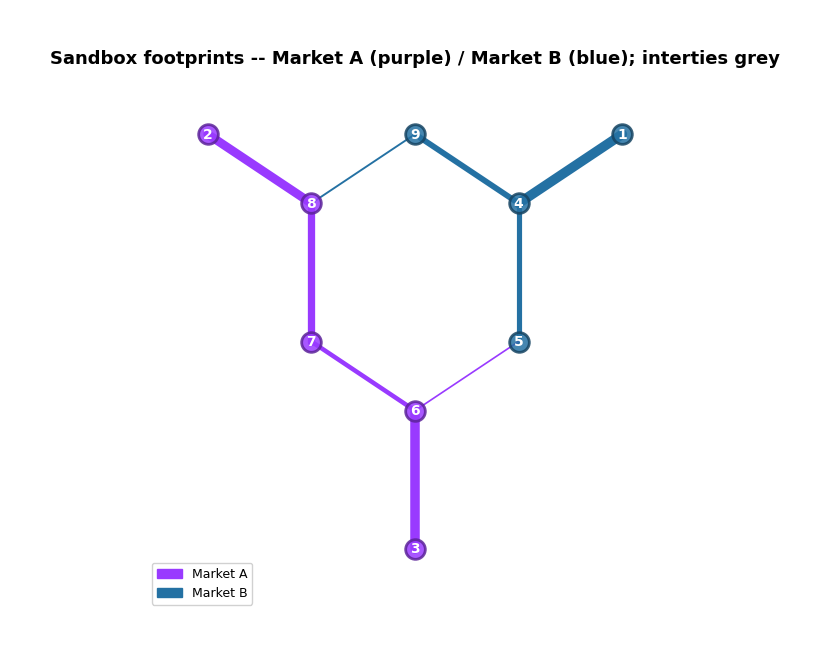

,ends,location,Market A,Market B
line,,,,
line_0,1-4,internal Market B,--,enforces
line_1,4-5,internal Market B,--,enforces
line_2,5-6,intertie,enforces,--
line_3,3-6,internal Market A,enforces,--
line_4,6-7,internal Market A,enforces,--
line_5,7-8,internal Market A,enforces,--
line_6,8-2,internal Market A,enforces,--
line_7,8-9,intertie,--,enforces
line_8,9-4,internal Market B,--,enforces


A energy $27.7 | B energy $50.0 | C_A+C_B = $13,659/h vs unified $8,941/h

overloads (actual):

['line_4']

,from,to,F[Market A],F[Market B],F^s,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,0.0,215.0,215.0,250.0,86.0,False
line_1,4,5,0.6,93.4,94.0,250.0,38.0,False
line_2,5,6,0.6,3.4,4.0,150.0,3.0,False
line_3,3,6,39.4,-0.0,39.4,300.0,13.0,False
line_4,6,7,40.0,3.4,43.4,40.0,109.0,True
line_5,7,8,-60.0,3.4,-56.6,250.0,23.0,False
line_6,8,2,-60.6,0.0,-60.6,250.0,24.0,False
line_7,8,9,0.6,3.4,4.0,250.0,2.0,False
line_8,9,4,0.6,-121.6,-121.0,250.0,48.0,False


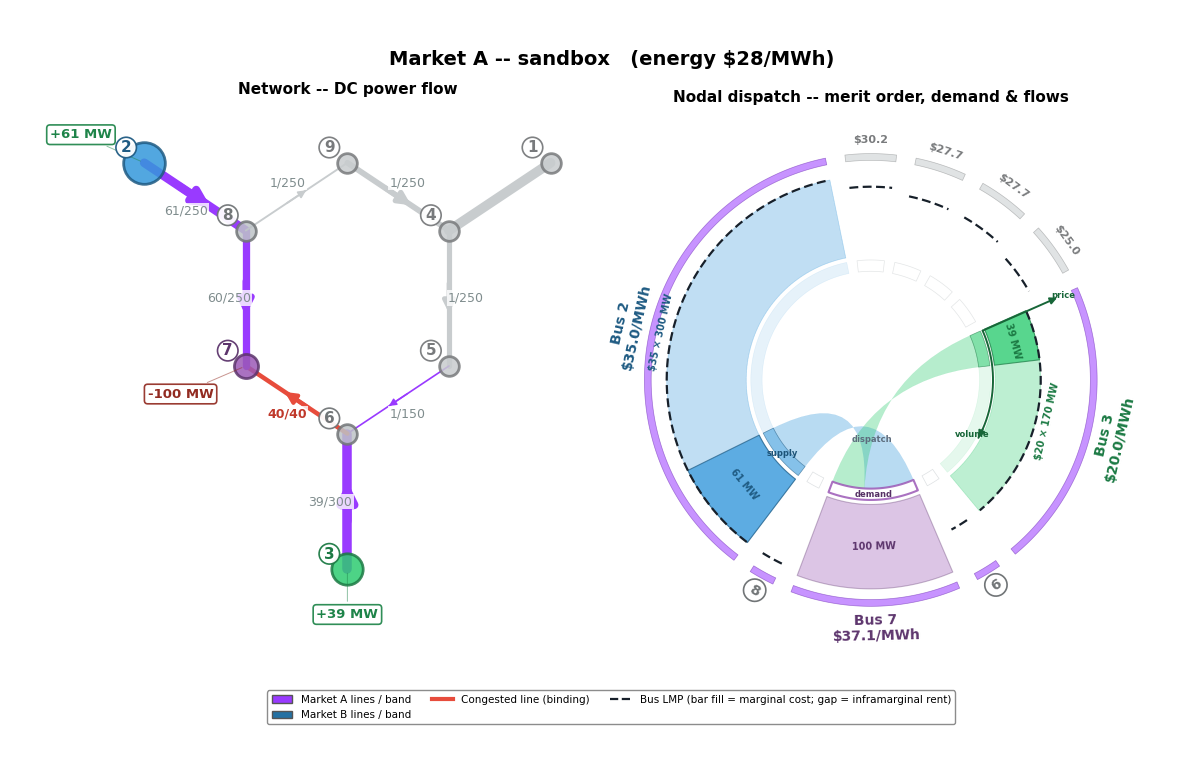

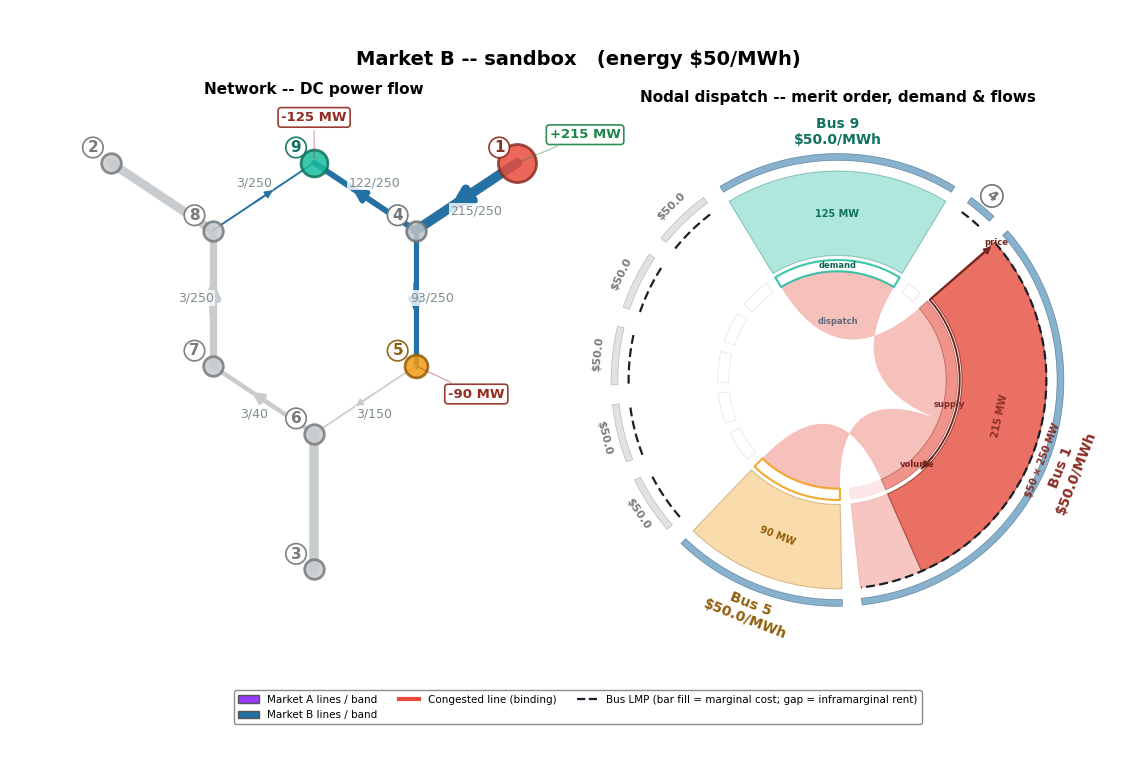

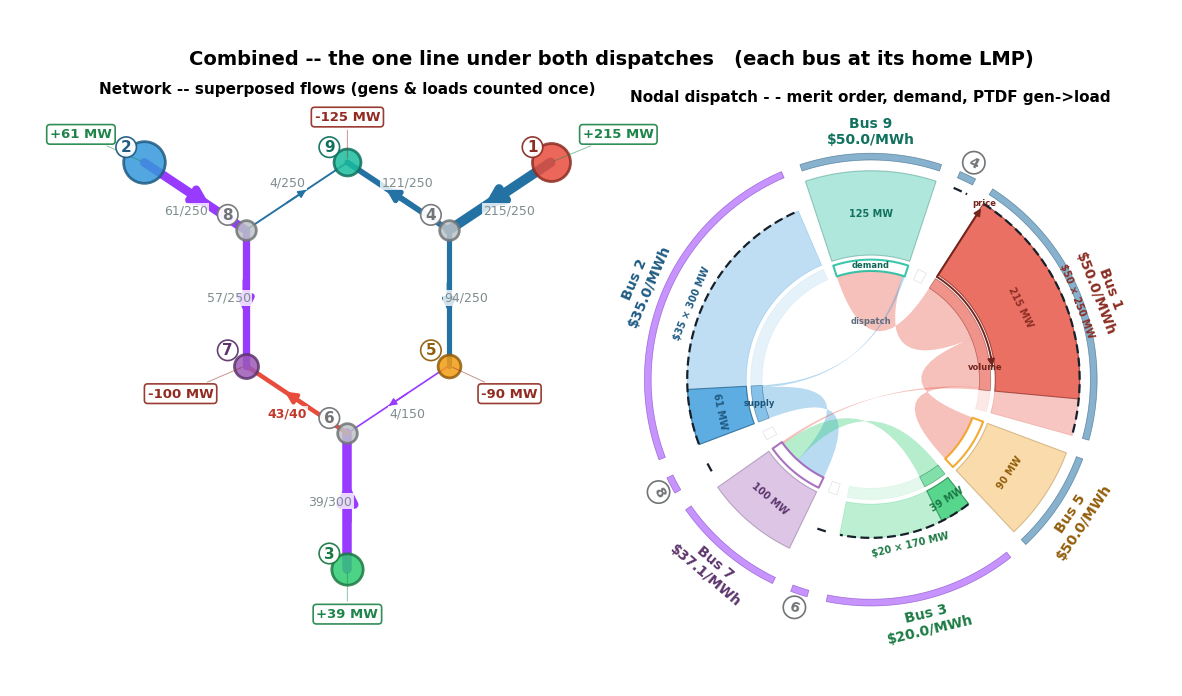

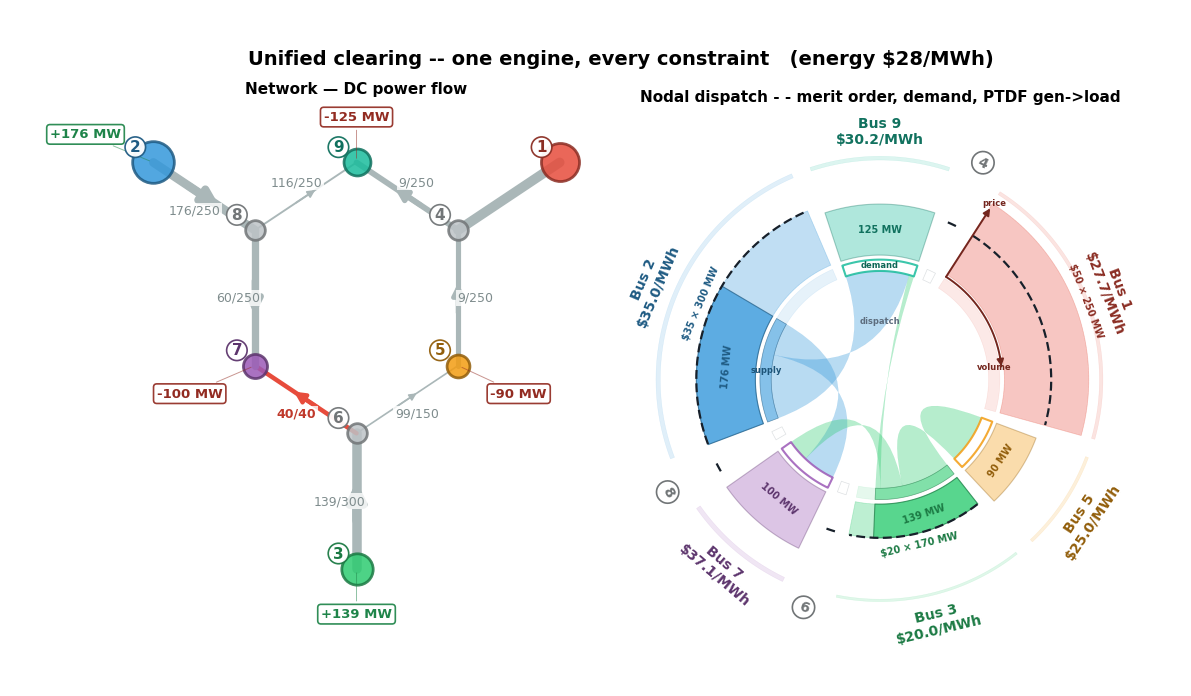

In [9]:
# -- EDIT -- free-form two-engine experiment ---------------------------------
RATINGS        = {'line_4': 40.0}
A_BUSES        = ['2', '8', '7', '6', '3']
B_BUSES        = ['1', '9', '4', '5']
A_MONITORED    = 'auto'       # M_mon: 'auto' = internal lines + allocated interties (the
B_MONITORED    = 'auto'       #   map-following default); 'all' = every line; [] = watch
                              #   nothing; or any list -- including the other footprint's lines.
A_ACTIVATED    = 'monitored'  # M_act: 'monitored' = enforce everything monitored (default);
B_ACTIVATED    = 'monitored'  #   or any list -- clipped to the monitored set.
INTERTIE_ALLOCATION = {'line_2': 'Market A', 'line_7': 'Market B'}   # used by 'auto'; an
                              # intertie absent here (or no longer crossing) goes unallocated
COSTS          = {}           # {'gen_1': 30.0}
LOADS_OVERRIDE = {}           # {'9': 160.0}
# ----------------------------------------------------------------------------
net = build_network(RATINGS); pt = compute_ptdf(net, slack_bus='1')
for b, v in LOADS_OVERRIDE.items(): LOADS[b] = v

# Rewire the Section-2 footprint config to the sandbox assignment (drives the
# figures' colours, bands, and monitored sets). Re-run Section 2 to restore.
MKT_DEFS = {'Market A': [str(b) for b in A_BUSES], 'Market B': [str(b) for b in B_BUSES]}
_tmp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, tie_label='intertie')
internal = {m: [l for l in pt.lines if _tmp.line_kind(pt, l) == ('internal', m)] for m in MKT_DEFS}
_seams_now = _tmp.ties
def _resolve(spec, m):
    if spec == 'all':  return list(pt.lines)
    if spec == 'auto': return internal[m] + [l for l, mg in INTERTIE_ALLOCATION.items()
                                             if mg == m and l in _seams_now]
    return [str(l) for l in spec]
MON = {'Market A': _resolve(A_MONITORED, 'Market A'),
       'Market B': _resolve(B_MONITORED, 'Market B')}
def _resolve_act(spec, m):
    lines = MON[m] if spec == 'monitored' else _resolve(spec, m)
    extra = [l for l in lines if l not in MON[m]]
    if extra:
        print(f'[!] {m}: {extra} activated but not monitored -> dropped (M_act within M_mon)')
    return [l for l in lines if l in MON[m]]
ACT = {'Market A': _resolve_act(A_ACTIVATED, 'Market A'),
       'Market B': _resolve_act(B_ACTIVATED, 'Market B')}
MONITORED_LINES = {m: list(MON[m]) for m in MKT_DEFS}
fp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, monitored=MONITORED_LINES, tie_label='intertie')
mkt_of = fp.fp_of; MKT_GROUPS = fp.groups(pt); seam_lines = fp.ties

# Configuration map (re-run after editing A_BUSES / B_BUSES).
import matplotlib.patches as _mp
_bcol_sb = {b: MARKET_COLORS[mkt_of(b)] for b in pt.buses}
_figm, _axm = plot_network_topology(
    net, supply_by_bus={}, demand_by_bus={}, bus_colors=_bcol_sb, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=fp.line_colors(pt),
    title='Sandbox footprints -- Market A (purple) / Market B (blue); interties grey')
_axm.legend(handles=[_mp.Patch(color=MARKET_COLORS[m], label=m) for m in MKT_DEFS],
            loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

A_x = make_engine('Market A', A_BUSES, activated=ACT['Market A'])
B_x = make_engine('Market B', B_BUSES, activated=ACT['Market B'])

# Line status under the sandbox configuration (location vs monitoring vs activation).
def _status_sb(l, m):
    if l in ACT[m]: return 'enforces'
    if l in MON[m]: return 'monitors'
    return '--'
_rows = []
for l in pt.lines:
    b0, b1 = pt.line_buses[pt.line_idx[l]]
    loc = 'intertie' if l in seam_lines else f'internal {mkt_of(b0)}'
    _rows.append({'line': l, 'ends': f'{b0}-{b1}', 'location': loc,
                  **{m: _status_sb(l, m) for m in MKT_DEFS}})
display(pd.DataFrame(_rows).set_index('line'))
for eng in (A_x, B_x):
    for g, c in COSTS.items():
        if g in eng.gens: eng.gens[g]['cost'] = c

rA_s = solve_engine_dispatch(pt, A_x, shed_price=SHED_PRICE)
rB_s = solve_engine_dispatch(pt, B_x, shed_price=SHED_PRICE)
uni_x = MarketEngine(name='Unified', gens={g: dict(s) for g, s in GEN_FLEET.items()},
                     loads=dict(LOADS), activated_lines='all')
for g, c in COSTS.items():
    if g in uni_x.gens: uni_x.gens[g]['cost'] = c
runi_x = solve_engine_dispatch(pt, uni_x, shed_price=SHED_PRICE)

print(f'A energy ${rA_s.energy_price:.1f} | B energy ${rB_s.energy_price:.1f} | '
      f'C_A+C_B = ${rA_s.total_cost + rB_s.total_cost:,.0f}/h vs unified ${runi_x.total_cost:,.0f}/h')

# ACTUAL line loading: count generators and loads ONCE across both books.
def _actual_flows(results):
    p = np.zeros(pt.n_bus)
    for r_ in results:
        for b, mw in r_.gen_by_bus.items():  p[pt.bus_idx[b]] += mw
        for b, mw in r_.load_by_bus.items(): p[pt.bus_idx[b]] -= mw
    return pt.ptdf @ p

f_act = _actual_flows([rA_s, rB_s])
pf_s = physical_flows(pt, [rA_s, rB_s]).rename(columns={'F_phys': 'F^s'})
pf_s['F^s'] = np.round(f_act, 1)
pf_s['loading_%'] = np.round(np.abs(f_act) / pf_s['rating'] * 100, 0)
pf_s['overload'] = np.abs(f_act) > pf_s['rating'] + 1e-6
print('overloads (actual):', pf_s[pf_s.overload].index.tolist() or 'none')
display(pf_s[['from', 'to', 'F[Market A]', 'F[Market B]', 'F^s', 'rating', 'loading_%', 'overload']])

# Each market's set, then the combined view of the one line.
for eng, r in ((A_x, rA_s), (B_x, rB_s)):
    market_figure(net, pt, eng, r,
                  suptitle=f'{eng.name} -- sandbox   (energy ${r.energy_price:.0f}/MWh)')
    plt.show()

supC, demC = {}, {}
for eng_, r_ in ((A_x, rA_s), (B_x, rB_s)):
    s_, d_ = to_supply_demand(eng_, r_)
    supC.update(s_); demC.update(d_)
host_lmp = {b: (rA_s if mkt_of(b) == 'Market A' else rB_s).lmp[b] for b in pt.buses}
fig, _ = plot_combined_letter(
    net, supC, demC,
    bus_colors=dict(BUS_COLORS), bus_lmps=host_lmp,
    bus_net_mw={b: float(rA_s.injection[pt.bus_idx[b]] + rB_s.injection[pt.bus_idx[b]])
                for b in pt.buses},
    network_show_lmp=False,
    line_flows={l: float(f) for l, f in zip(pt.lines, f_act)},
    line_widths=susceptance_widths(pt), line_colors=fp.line_colors(pt),
    constrained_lines={l for l, f in zip(pt.lines, f_act)
                       if abs(f) > pt.s_nom[pt.line_idx[l]] + 1e-6},
    flows=nodal_plot.compute_ptdf_flows(net, supC, demC),
    lmp_line=True, bus_groups=MKT_GROUPS, group_colors=dict(MARKET_COLORS),
    show_group_labels=False,
    all_buses=pt.buses, sector_order=RING_ORDER, bus_coords=COORDS, center_bus=CENTER_BUS,
    annotate_roles=True, axis_key=True,
    title_left='Network -- superposed flows (gens & loads counted once)',
    suptitle='Combined -- the one line under both dispatches   (each bus at its home LMP)')
plt.show()

supU, demU = to_supply_demand(uni_x, runi_x)
bindU = {l for l, mu in runi_x.line_dual.items() if abs(mu) > 1e-3}
fig, _ = plot_combined_letter(
    net, supU, demU,
    bus_colors=dict(BUS_COLORS), bus_lmps=runi_x.lmp,
    bus_net_mw={b: float(runi_x.injection[pt.bus_idx[b]]) for b in pt.buses},
    network_show_lmp=False,
    line_flows={l: runi_x.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=bindU,
    flows=nodal_plot.compute_ptdf_flows(net, supU, demU),
    clearing_price=runi_x.energy_price, lmp_line=True,
    annotate_roles=True, axis_key=True,
    all_buses=pt.buses, sector_order=RING_ORDER, bus_coords=COORDS, center_bus=CENTER_BUS,
    suptitle=f'Unified clearing -- one engine, every constraint   '
             f'(energy ${runi_x.energy_price:.0f}/MWh)')
plt.show()


## 6. Where this goes

Two things a seam leaves unmanaged, two notebooks:

- **The shared constraints.** Section 4's superposition — the flow neither
  engine prices — is the congestion-management problem: reserve headroom for the
  neighbour ex ante, or overload and redispatch after the fact. That trade-off,
  deterministic and then under uncertainty, is **204**. The contingency variant
  is 302.
- **The interchange.** Nothing in either engine schedules power across the
  partition. Every bus carries a price from each engine, the gap is the value of
  moving a megawatt across the seam, and whoever moves it must commit before
  either market clears. The seam dual gap, the scheduled interchange, the
  participant-initiated trade, and the risk the trader carries are **205**; 212
  works the wheeling case, and 222/322 the placement (SP-Tie vs GAP-Tie)
  question.


---
